In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import csv
import numpy as np
from sklearn.preprocessing import LabelEncoder
from scipy.optimize import differential_evolution
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score, LeaveOneOut
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
import warnings
warnings.filterwarnings("ignore")

In [8]:
conn = sqlite3.connect("healing.db")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('snapshots',), ('sqlite_sequence',), ('healing_events',), ('candidate_scores',), ('learned_weights',)]


In [9]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()

for (table,) in tables:
    df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
    df.to_csv(f"{table}_2.csv", index=False)
    print(f"Exported: {table}_2.csv")

conn.close()

Exported: snapshots_2.csv
Exported: sqlite_sequence_2.csv
Exported: healing_events_2.csv
Exported: candidate_scores_2.csv
Exported: learned_weights_2.csv


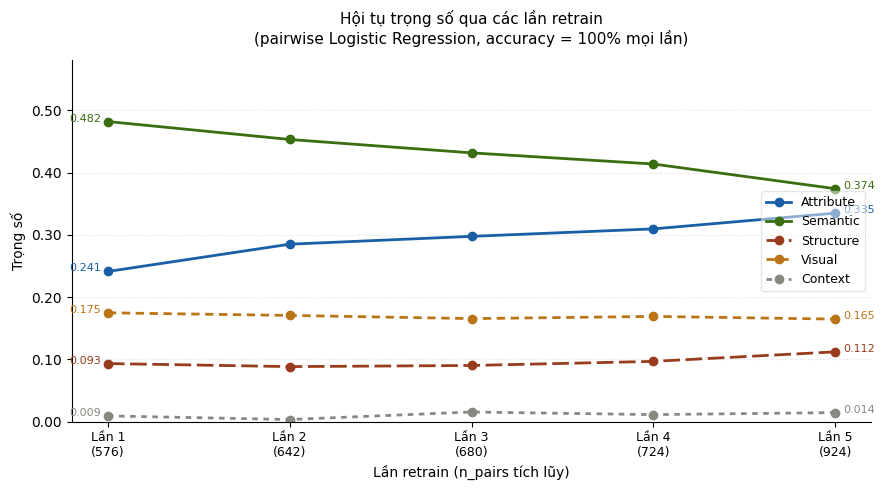

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

data = {
    "Lần 1\n(576)":  [0.2411, 0.4819, 0.0932, 0.1747, 0.0091],
    "Lần 2\n(642)":  [0.2849, 0.4531, 0.0883, 0.1705, 0.0033],
    "Lần 3\n(680)":  [0.2975, 0.4316, 0.0901, 0.1654, 0.0154],
    "Lần 4\n(724)":  [0.3095, 0.4137, 0.0967, 0.1689, 0.0112],
    "Lần 5\n(924)":  [0.3348, 0.3741, 0.1120, 0.1646, 0.0144],
}

labels   = list(data.keys())
values   = np.array(list(data.values()))   # shape (5, 5)
dims     = ["Attribute", "Semantic", "Structure", "Visual", "Context"]
colors   = ["#185FA5", "#3B6D11", "#993C1D", "#BA7517", "#888780"]
dashes   = [(None,None), (None,None), (6,2), (3,2), (2,2)]
x        = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 5))

for i, (dim, color, dash) in enumerate(zip(dims, colors, dashes)):
    ls = "--" if dash[0] else "-"
    ax.plot(x, values[:, i], marker="o", label=dim,
            color=color, linewidth=2, markersize=6,
            linestyle=ls, dashes=dash if dash[0] else (None, None))
    # annotate điểm đầu và cuối
    ax.annotate(f"{values[0, i]:.3f}", (0, values[0, i]),
                textcoords="offset points", xytext=(-28, 0),
                fontsize=8, color=color)
    ax.annotate(f"{values[-1, i]:.3f}", (len(x)-1, values[-1, i]),
                textcoords="offset points", xytext=(6, 0),
                fontsize=8, color=color)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 0.58)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.set_ylabel("Trọng số", fontsize=10)
ax.set_xlabel("Lần retrain (n_pairs tích lũy)", fontsize=10)
ax.set_title("Hội tụ trọng số qua các lần retrain\n(pairwise Logistic Regression, accuracy = 100% mọi lần)",
             fontsize=11, pad=12)
ax.legend(loc="center right", fontsize=9, framealpha=0.5)
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("weight_convergence.png", dpi=150, bbox_inches="tight")
plt.show()